# 1. Question Closeness and Decomposition

This notebook does two things:

1. **Question decomposition** — split each market question into a *qualitative semantic core* (the underlying event) and a *quantitative parametric part* (date/time deadlines, numeric thresholds, count conditions). This separation is necessary to distinguish true duplicates from reframings.

2. **Closeness evaluation** — compute pairwise similarity signals and evaluate them against weak labels, including a new reframing-aware taxonomy.

### Closeness taxonomy

| Type | Qualitative similarity | Quantitative part | Example |
|---|---|---|---|
| `EXACT_DUPLICATE` | very high | identical | same question, same deadline |
| `REFRAMING` | very high | different | "end by 7 days" vs "end by 30 days" |
| `RELATED_EVENT` | moderate | varies | same topic, different events |
| `UNRELATED` | low | varies | unrelated questions |

### Why this matters for the benchmark

Side Idea 7 (outdated-prior belief update) requires excluding reframings: we want one canonical question per event family, not multiple parameterized variants of the same underlying question. This notebook provides the tooling to do that split.

## Imports and configuration

In [1]:
import ast
import itertools
import re
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics.pairwise import cosine_similarity

from polymarket_research.data.canonical import CanonicalDatasetBuilder
from polymarket_research.data.raw import RawExternalCovariates, RawPolymarketHandle
from polymarket_research.utils import setup_root

REPO_ROOT = setup_root()
CANONICAL_CACHE_DIR = REPO_ROOT / 'research_notebooks' / 'running_artefacts_new' / 'canonical_dataset'

# ── Scope: NO domain filter.
# The 'domain' column is currently 'unassigned' for all markets.
# Domains will be *derived* from question-closeness results in this notebook,
# not used as input. We filter purely by probability coverage and volume.
MARKET_LIMIT = None
MARKET_ORDER = None  # one of: None, 'latest', 'largest'
MAX_MARKETS = 50000           # cap to keep O(N²) pairwise computation tractable
MIN_PROBABILITY_ROWS = 288  # at least ~1 day of 5-min snapshots
MIN_VOLUME = 1000           # focus on markets with some trading activity
RESAMPLE_FREQ = '1h'
TOP_K = 5

# Closeness taxonomy thresholds
EXACT_DUP_THRESHOLD = 0.95   # qual-core cosine >= this + same quant → EXACT_DUPLICATE
RELATED_THRESHOLD   = 0.40   # qual-core cosine >= this → RELATED_EVENT

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', None)


## Load canonical dataset

We use the canonical resolved-markets layer. If no parquet cache exists, we build from the raw layer.

In [2]:
if (CANONICAL_CACHE_DIR / 'markets.parquet').exists() and MARKET_LIMIT is None and MARKET_ORDER is None:
    from polymarket_research.data.canonical import CanonicalDataset
    canonical = CanonicalDataset.from_parquet(CANONICAL_CACHE_DIR)
    print('Loaded canonical from parquet cache:', CANONICAL_CACHE_DIR)
else:
    raw_handle = RawPolymarketHandle()
    raw_bundle = raw_handle.load_bundle(
        include_market_universe=False,
        include_download_manifest=False,
        include_probabilities=True,
        include_raw_trades=False,
        market_limit=MARKET_LIMIT,
        market_order=MARKET_ORDER,
    )
    raw_external = RawExternalCovariates().load()
    canonical = CanonicalDatasetBuilder(
        raw_dataset=raw_bundle,
        raw_external=raw_external,
        resolved_only=True,
    ).build()
    if MARKET_LIMIT is None and MARKET_ORDER is None:
        canonical.save(CANONICAL_CACHE_DIR)
    print('Built canonical from SQLite')

all_markets = canonical.markets.copy()
probabilities = canonical.probabilities.copy()
print(f'Canonical resolved markets: {len(all_markets)}')
print('Market limit:', MARKET_LIMIT)
print('Market order:', MARKET_ORDER)
display(all_markets[['market_id', 'question', 'domain', 'family_id', 'volume_num']].head(5))


Loaded canonical from parquet cache: /Users/sneddy/research/polymarket_research/research_notebooks/running_artefacts_new/canonical_dataset
Canonical resolved markets: 15662
Market limit: None
Market order: None


,market_id,question,domain,family_id,volume_num
0,1914442,"Will Hegseth say ""AI"" or ""Cyber"" during press conference?",unassigned,unassigned::::hegseth say ai or cyber during,38222.744674
1,1912772,"Trump announces US x Iran ceasefire end by April 8, 2026?",unassigned,unassigned::::trump announces us x iran ceasefire,38220.348645
2,1908626,Trump announces Hormuz deadline extension today?,unassigned,unassigned::::trump announces hormuz deadline extension today,987122.280619
3,1891746,"Will Trump say ""Strait"" or ""Hormuz"" during events with Rutte?",unassigned,unassigned::::trump say strait or hormuz during,27053.816874
4,1882888,Will Trump's remarks not air?,unassigned,unassigned::::trump s remarks not air,33098.189315


## Filter working scope

In [3]:
markets = (
    all_markets[
        all_markets['probability_rows'].fillna(0).ge(MIN_PROBABILITY_ROWS)
        & all_markets['volume_num'].fillna(0).ge(MIN_VOLUME)
    ]
    .sort_values('volume_num', ascending=False)
    .head(MAX_MARKETS)
    .reset_index(drop=True)
    .copy()
)

print(f'Working scope: {len(markets)} markets')
print(f'  probability_rows >= {MIN_PROBABILITY_ROWS}: covers {all_markets["probability_rows"].fillna(0).ge(MIN_PROBABILITY_ROWS).sum()} markets in total')
print(f'  volume_num >= {MIN_VOLUME}: covers {all_markets["volume_num"].fillna(0).ge(MIN_VOLUME).sum()} markets in total')
display(markets[["market_id", "question", "volume_num", "probability_rows", "family_id"]].head(10))


Working scope: 8460 markets
  probability_rows >= 288: covers 8460 markets in total
  volume_num >= 1000: covers 15662 markets in total


,market_id,question,volume_num,probability_rows,family_id
0,546814,Will Zelenskyy wear a suit before July?,2.422312e+08,13557.0,unassigned::::zelenskyy wear suit before july
1,601697,Fed decreases interest rates by 50+ bps after January 2026 meeting?,2.350652e+08,4005.0,unassigned::::fed decreases interest rates 50 bps
2,601700,Fed increases interest rates by 25+ bps after January 2026 meeting?,2.164557e+08,38298.0,unassigned::::fed increases interest rates 25 bps
3,654415,Will the Fed increase interest rates by 25+ bps after the March 2026 meeting?,1.729721e+08,40145.0,unassigned::::fed increase interest rates 25 bps
4,570360,Fed decreases interest rates by 50+ bps after December 2025 meeting?,1.615744e+08,37995.0,unassigned::::fed decreases interest rates 50 bps
5,680392,US government shutdown Saturday?,1.572966e+08,23726.0,unassigned::::us government shutdown saturday
6,538932,Will Zohran Mamdani win the 2025 NYC mayoral election?,1.432549e+08,56585.0,unassigned::::zohran mamdani win 2025 nyc mayoral
7,570363,Fed increases interest rates by 25+ bps after December 2025 meeting?,1.331736e+08,37885.0,unassigned::::fed increases interest rates 25 bps
8,1180303,Khamenei out as Supreme Leader of Iran by February 28?,1.311150e+08,14106.0,unassigned::::khamenei out as supreme leader iran
9,529278,Will Frances Fitzgerald win the Irish Presidential Election?,1.150672e+08,62889.0,unassigned::::frances fitzgerald win irish presidential election


---

# Part 1: Question Decomposition

We split each question into:
- **Qualitative core**: the underlying event — who, what, which entity.
- **Quantitative part**: numeric or temporal conditions — deadlines, thresholds, counts.

The decomposition uses regex patterns. We also use structural columns (`event_series_slug`, `group_item_title`, `neg_risk`) as weak validation signals.

In [4]:
# ─────────────────────────────────────────────────────────────────
# QuestionDecomposer
# ─────────────────────────────────────────────────────────────────

# Trigger patterns answer: when / by when does this resolve?
# Event text answers: what is the thing that might happen?
#
# Important modeling choice:
# - temporal / activation clauses like "before July", "after January 2026 meeting",
#   "by March 31", "Saturday" belong to trigger
# - scale / magnitude phrases like "by 50+ bps" remain part of the event
#
# We also resolve overlapping regex matches by keeping the longest leftmost span,
# so "by march 31" wins over a nested standalone "march 31".
_MONTH = r'(?:jan(?:uary)?|feb(?:ruary)?|mar(?:ch)?|apr(?:il)?|may|jun(?:e)?|jul(?:y)?|aug(?:ust)?|sep(?:tember)?|oct(?:ober)?|nov(?:ember)?|dec(?:ember)?)'
_DOW = r'(?:monday|tuesday|wednesday|thursday|friday|saturday|sunday)'
_QUARTER = r'(?:q[1-4](?:\s+\d{4})?|quarter\s+[1-4](?:\s+\d{4})?|h[12]\s+\d{4})'
_MEETING = rf'(?:the\s+)?{_MONTH}\s+\d{{4}}\s+meeting'
_DATE_POINT = rf'(?:{_MEETING}|(?:the\s+end\s+of\s+)?{_MONTH}(?:\s+\d{{1,2}}(?:,?\s+\d{{4}})?|\s+\d{{4}})?|(?:the\s+end\s+of\s+)?{_QUARTER}|(?:the\s+end\s+of\s+)?\d{{4}}|{_DOW})'
_TRIGGER_PATTERNS = [
    rf'\b(?:by|before|after|on)\s+{_DATE_POINT}\b',
    rf'\b{_DOW}\b',
    r'\bwithin\s+\d+\s+(?:day|week|month|hour|year)s?\b',
    r'\bin\s+\d{4}\b',
    r'\bby\s+(?:the\s+)?end\s+of\s+\d{4}\b',
    r'\bfirst\s+\d+\s+(?:day|week|month|hour)s?\b',
    r'\bnext\s+\d+\s+(?:day|week|month|hour)s?\b',
]
_TRIGGER_COMPILED = [re.compile(p, re.IGNORECASE) for p in _TRIGGER_PATTERNS]


def _normalize(text: str) -> str:
    text = str(text or '').lower()
    text = re.sub(r'[^a-z0-9\s\$%,.+]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def _select_non_overlapping_matches(patterns: list, text: str) -> list:
    candidates = []
    for order, pat in enumerate(patterns):
        for m in pat.finditer(text):
            candidates.append({
                'start': m.start(),
                'end': m.end(),
                'text': m.group().strip(),
                'order': order,
            })

    # Longest-leftmost wins; pattern order breaks ties.
    candidates.sort(key=lambda x: (x['start'], -(x['end'] - x['start']), x['order']))

    selected = []
    for cand in candidates:
        if any(not (cand['end'] <= kept['start'] or cand['start'] >= kept['end']) for kept in selected):
            continue
        selected.append(cand)

    selected.sort(key=lambda x: x['start'])
    return selected


def _remove_spans(text: str, spans: list) -> str:
    pieces = []
    cursor = 0
    for span in spans:
        pieces.append(text[cursor:span['start']])
        cursor = span['end']
    pieces.append(text[cursor:])
    cleaned = ' '.join(pieces)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned.strip(' ,')


@dataclass
class DecomposedQuestion:
    original: str
    decoupled_event: str
    decoupled_trigger: str
    trigger_candidates: list
    has_trigger: bool
    qual_core: str        # backward-compatible alias for decoupled_event
    quant_spans: list     # backward-compatible alias for [decoupled_trigger]
    has_quant: bool       # backward-compatible alias for has_trigger


def decompose_question(question: str) -> DecomposedQuestion:
    """Split a question into decoupled event and trigger spans."""
    norm = _normalize(question)
    trigger_matches = _select_non_overlapping_matches(_TRIGGER_COMPILED, norm)
    trigger_candidates = list(dict.fromkeys(match['text'] for match in trigger_matches))
    # Heuristic: when multiple trigger candidates exist, prefer the last one.
    # In market questions this is often the market-resolution clause,
    # while earlier temporal spans belong to the embedded event description.
    decoupled_trigger = trigger_candidates[-1] if trigger_candidates else ''
    chosen_matches = [trigger_matches[-1]] if trigger_matches else []
    decoupled_event = _remove_spans(norm, chosen_matches)
    return DecomposedQuestion(
        original=question,
        decoupled_event=decoupled_event,
        decoupled_trigger=decoupled_trigger,
        trigger_candidates=trigger_candidates,
        has_trigger=bool(decoupled_trigger),
        qual_core=decoupled_event,
        quant_spans=[decoupled_trigger] if decoupled_trigger else [],
        has_quant=bool(decoupled_trigger),
    )


# Apply decomposition
decomposed = markets['question'].apply(decompose_question)
markets['decoupled_event'] = [d.decoupled_event for d in decomposed]
markets['decoupled_trigger'] = [d.decoupled_trigger for d in decomposed]
markets['trigger_candidates'] = [d.trigger_candidates for d in decomposed]
markets['has_trigger'] = [d.has_trigger for d in decomposed]

# Backward-compatible aliases used later in the notebook.
markets['qual_core'] = [d.qual_core for d in decomposed]
markets['quant_spans'] = [d.quant_spans for d in decomposed]
markets['has_quant'] = [d.has_quant for d in decomposed]

print(f'Markets with trigger condition: {markets["has_trigger"].sum()} / {len(markets)} ({100*markets["has_trigger"].mean():.1f}%)')
display(markets[['question', 'decoupled_event', 'decoupled_trigger', 'has_trigger']].head(20))

Markets with trigger condition: 3412 / 8460 (40.3%)


,question,decoupled_event,decoupled_trigger,has_trigger
0,Will Zelenskyy wear a suit before July?,will zelenskyy wear a suit,before july,True
1,Fed decreases interest rates by 50+ bps after January 2026 meeting?,fed decreases interest rates by 50+ bps,after january 2026 meeting,True
2,Fed increases interest rates by 25+ bps after January 2026 meeting?,fed increases interest rates by 25+ bps,after january 2026 meeting,True
3,Will the Fed increase interest rates by 25+ bps after the March 2026 meeting?,will the fed increase interest rates by 25+ bps,after the march 2026 meeting,True
4,Fed decreases interest rates by 50+ bps after December 2025 meeting?,fed decreases interest rates by 50+ bps,after december 2025 meeting,True
5,US government shutdown Saturday?,us government shutdown,saturday,True
6,Will Zohran Mamdani win the 2025 NYC mayoral election?,will zohran mamdani win the 2025 nyc mayoral election,,False
7,Fed increases interest rates by 25+ bps after December 2025 meeting?,fed increases interest rates by 25+ bps,after december 2025 meeting,True
8,Khamenei out as Supreme Leader of Iran by February 28?,khamenei out as supreme leader of iran,by february 28,True
9,Will Frances Fitzgerald win the Irish Presidential Election?,will frances fitzgerald win the irish presidential election,,False


## Validate decomposition with structural columns

We check whether `has_trigger` is consistent with structural markers:
- `neg_risk`: Polymarket's neg-risk mechanism creates parameterized variants.
- `event_series_slug`: markets in the same series often differ only in parameters.
- `group_item_title`: explicitly captures the variant title (e.g. "7 days", "30 days").

In [5]:
# Retrieve structural columns from raw market_universe if available
struct_cols = ['market_id', 'neg_risk', 'event_series_slug', 'group_item_title']
available_struct_cols = [c for c in struct_cols if c in all_markets.columns]

if len(available_struct_cols) > 1:
    struct = all_markets[available_struct_cols].copy()
    markets = markets.merge(struct, on='market_id', how='left')

    if 'neg_risk' in markets.columns:
        display(Markdown('### has_quant rate by neg_risk flag'))
        display(
            markets.groupby('neg_risk')['has_quant']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'quant_rate', 'count': 'n'})
        )

    if 'event_series_slug' in markets.columns:
        display(Markdown('### Largest event series'))
        series_sizes = markets.groupby('event_series_slug').size().sort_values(ascending=False).head(10)
        display(series_sizes)

    if 'group_item_title' in markets.columns:
        display(Markdown('### Sample group_item_title (parametric labels)'))
        display(markets[markets['group_item_title'].notna()][['question', 'group_item_title', 'qual_core', 'quant_spans']].head(15))
else:
    print('Structural columns not available in canonical dataset — skipping validation.')

## Decomposition diagnostics

How does the decoupled event differ in length from the original question? How many trigger spans are extracted per market?

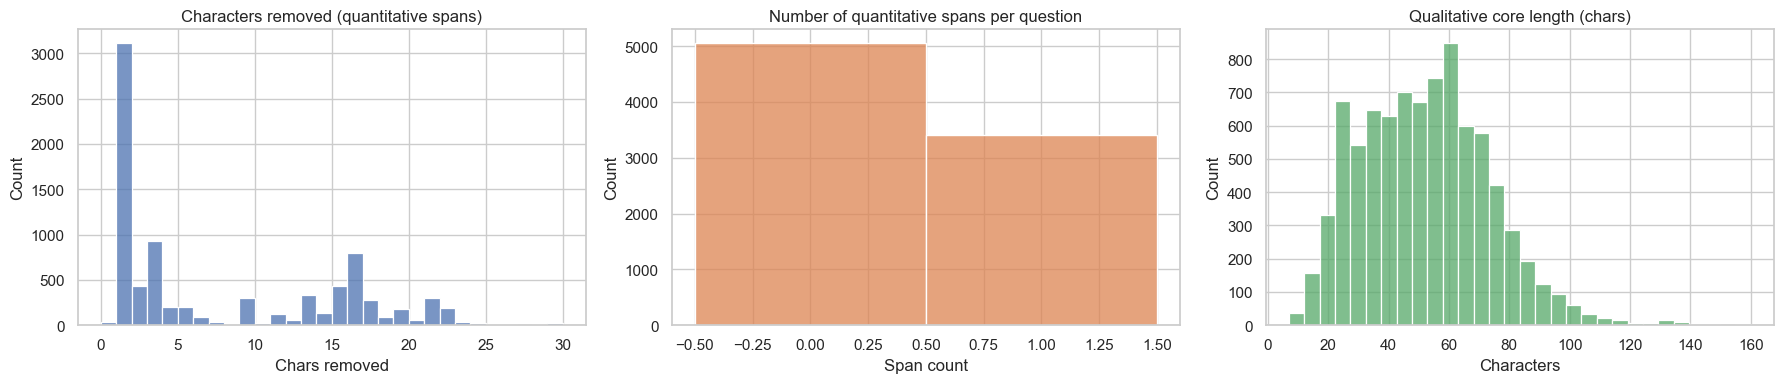

### Sample: questions with most quantitative content

,question,qual_core,quant_spans
0,Will Zelenskyy wear a suit before July?,will zelenskyy wear a suit,[before july]
3960,Will Trump and Mamdani shake hands for less than 2 seconds on November 21 2025?,will trump and mamdani shake hands for less than 2 seconds,[on november 21 2025]
3974,Trump strikes another drug boat by Oct 31?,trump strikes another drug boat,[by oct 31]
3973,North Korea missile launch by November 30?,north korea missile launch,[by november 30]
3971,"Will Trump say ""Crypto"" or ""Bitcoin"" during the America Business Forum on November 5?",will trump say crypto or bitcoin during the america business forum,[on november 5]
3970,"Will between 221 and 222 U.S. House members vote ""Yea"" on the next funding bill by November 30?",will between 221 and 222 u.s. house members vote yea on the next funding bill,[by november 30]
3968,TikTok removed from App Store by September 30?,tiktok removed from app store,[by september 30]
3962,"Will Trump say ""Crypto"" or ""Bitcoin"" during the UK state banquet on September 17?",will trump say crypto or bitcoin during the uk state banquet,[on september 17]
3959,"Will Iran conduct a military action against Israel on March 28, 2026?",will iran conduct a military action against israel,"[on march 28, 2026]"
3978,Will OpenAI be the first company to have an AI model hit 1500 on Chatbot Arena by June 30 2026?,will openai be the first company to have an ai model hit 1500 on chatbot arena,[by june 30 2026]


In [6]:
markets['original_len'] = markets['question'].str.len()
markets['qual_len'] = markets['qual_core'].str.len()
markets['quant_char_removed'] = markets['original_len'] - markets['qual_len']
markets['n_quant_spans'] = markets['quant_spans'].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(markets['quant_char_removed'].clip(0, 100), bins=30, color='#4c72b0', ax=axes[0])
axes[0].set_title('Characters removed (quantitative spans)')
axes[0].set_xlabel('Chars removed')

sns.histplot(markets['n_quant_spans'], bins=range(0, 8), discrete=True, color='#dd8452', ax=axes[1])
axes[1].set_title('Number of quantitative spans per question')
axes[1].set_xlabel('Span count')

sns.histplot(markets['qual_len'], bins=30, color='#55a868', ax=axes[2])
axes[2].set_title('Qualitative core length (chars)')
axes[2].set_xlabel('Characters')

plt.tight_layout()
plt.show()

display(Markdown('### Sample: questions with most quantitative content'))
display(
    markets.sort_values('n_quant_spans', ascending=False)[['question', 'qual_core', 'quant_spans']].head(10)
)

---

# Part 2: Pairwise Closeness Signals

We compute:
- **Full-text cosine**: TF-IDF on the original question + description + tags (from existing pipeline).
- **Qual-core cosine**: TF-IDF on the qualitative core only — the key new signal.
- **Tag Jaccard**: overlap of tag sets.
- **Time overlap**: Jaccard of market lifetime windows.
- **Resolution source match**: same resolution URL.
- **Return correlation**: absolute Pearson correlation of hourly probability changes.
- **Combined score**: weighted combination.

In [7]:
# ─── helpers (reproduced from tickers_closeness for self-containment) ─────────

def parse_listish(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, list):
        return [str(x).strip() for x in value if str(x).strip()]
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except Exception:
        pass
    sep = '|' if '|' in text else ','
    return [p.strip() for p in text.split(sep) if p.strip()]


def tag_jaccard(tags_a, tags_b):
    a = set(parse_listish(tags_a))
    b = set(parse_listish(tags_b))
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)


def safe_corr(s_a: pd.Series, s_b: pd.Series, min_points: int = 12) -> float:
    pair = pd.concat([s_a, s_b], axis=1).dropna()
    if len(pair) < min_points:
        return np.nan
    a = pair.iloc[:, 0].to_numpy(float)
    b = pair.iloc[:, 1].to_numpy(float)
    if np.nanstd(a) <= 1e-12 or np.nanstd(b) <= 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def safe_auc(y_true, score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, score)


def safe_ap(y_true, score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, score)


def recall_at_k(pair_df: pd.DataFrame, score_col: str, label_col: str, k: int = 5) -> float:
    recalls = []
    for _, group in pair_df.groupby('market_id_a', sort=False):
        if group[label_col].sum() == 0:
            continue
        top = group.nlargest(k, score_col)
        recalls.append(float(top[label_col].sum() > 0))
    return float(np.mean(recalls)) if recalls else np.nan

In [8]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
TOKEN_RE = re.compile(r"(?u)\b[\w$%.+-]+\b")

def lemma_tokenizer(text: str) -> list[str]:
    text = str(text or '').lower()
    tokens = TOKEN_RE.findall(text)
    return [lemmatizer.lemmatize(tok) for tok in tokens if len(tok) > 1]

# Start simple: similarity on the raw question text, including quantitative parts.
markets['question_for_similarity'] = markets['question'].fillna('')

vec_question = TfidfVectorizer(
    min_df=2,
    max_features=5000,
    ngram_range=(1, 2),
    tokenizer=lemma_tokenizer,
    preprocessor=None,
    lowercase=False,
    token_pattern=None,
)

tfidf_question = vec_question.fit_transform(markets['question_for_similarity'])
cos_question = cosine_similarity(tfidf_question)   # shape (N, N)

print('TF-IDF matrix built on raw question text')
print(f'  Vocab size: {len(vec_question.vocabulary_)}')
print('  Lemmatization: WordNetLemmatizer')
print('  N-grams: unigrams + bigrams')


[nltk_data] Downloading package wordnet to /Users/sneddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


TF-IDF matrix built on raw question text
  Vocab size: 5000
  Lemmatization: WordNetLemmatizer
  N-grams: unigrams + bigrams


Explained variance by PCA(2): 0.035
Cluster sizes:


,n
cluster,
-1,560
0,52
1,37
2,51
3,8
...,...
416,3
417,3
418,4


/var/folders/zv/mjsbg2dx4q79c1gbwtlhbk180000gp/T/ipykernel_20621/3644504296.py:53: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


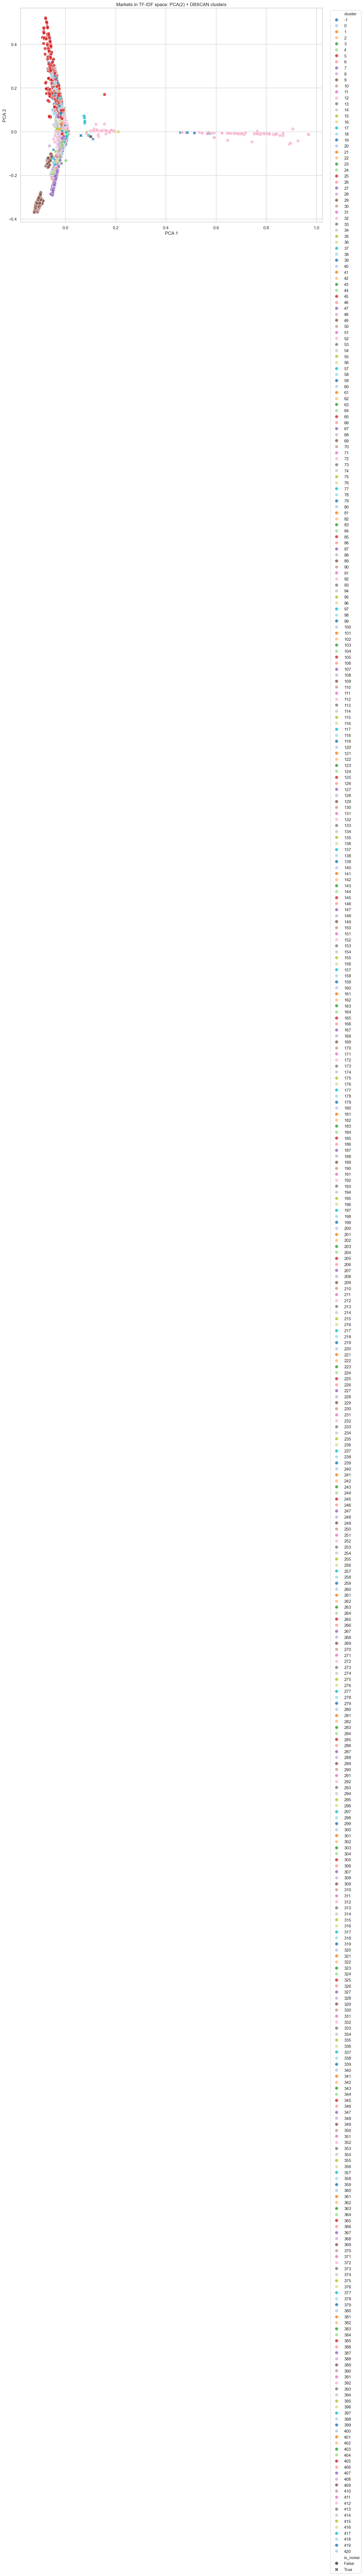

### Sample points per cluster

**noise**

,market_id,question
0,546814,Will Zelenskyy wear a suit before July?
1,551963,Xi Jinping out in 2025?
2,566331,Will Polymarket US go live in 2025?
3,552649,Israel x Iran ceasefire before July?
4,563368,Will Satoshi move any Bitcoin in 2025?
5,571191,Will Rob Riggle win the 2025 National Heads-Up Poker Championship?
6,1192781,"Will Melania say ""Career"" during AI talk on Friday?"
7,1144023,U.S. anti-cartel ground operation in Mexico by January 31?
8,532741,US military action against Iran before July?
9,525362,Will George Russell be the 2025 Drivers Champion?


**cluster 0**

,market_id,question
0,601697,Fed decreases interest rates by 50+ bps after January 2026 meeting?
1,601700,Fed increases interest rates by 25+ bps after January 2026 meeting?
2,654415,Will the Fed increase interest rates by 25+ bps after the March 2026 meeting?
3,570360,Fed decreases interest rates by 50+ bps after December 2025 meeting?
4,570363,Fed increases interest rates by 25+ bps after December 2025 meeting?
5,601699,No change in Fed interest rates after January 2026 meeting?
6,553813,Fed increases interest rates by 25+ bps after October 2025 meeting?
7,601698,Fed decreases interest rates by 25 bps after January 2026 meeting?
8,654413,Will the Fed decrease interest rates by 25 bps after the March 2026 meeting?
9,542539,No change in Fed interest rates after September 2025 meeting?


...

,market_id,question
0,1348633,"Will Bernie Sanders say ""Obama"" during the Fighting Oligarchy rally?"
1,1348630,"Will Bernie Sanders say ""Epstein"" during the Fighting Oligarchy rally?"
2,1348620,"Will Bernie Sanders say ""Trump"" 15+ times during the Fighting Oligarchy rally?"
3,1348628,"Will Bernie Sanders say ""Affordability"" during the Fighting Oligarchy rally?"


**cluster 419**

,market_id,question
0,1733837,"Will Trump say ""Cuba"" during the FII PRIORITY Summit?"
1,631442,"Will Trump say ""Phase Two"" during Egypt summit?"
2,631433,"Will Trump say ""Hostage"" 5+ times during Egypt summit?"


**cluster 420**

,market_id,question
0,1006303,Will Jean Smart win Best Actress in a Comedy Series at the 2026 SAG Awards?
1,1005749,Will Erin Doherty win Best Actress in a Television Movie or Limited Series at the 2026 SAG Awards?
2,1005914,Will Rhea Seehorn win Best Actress in a Drama Series at the 2026 SAG Awards?


In [9]:
# Visualize text similarity with PCA(2) and cluster with DBSCAN
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Choose which representation to inspect:
# - tfidf_question
# - tfidf_qual
# If you followed the simplified setup, use tfidf_question.
X = tfidf_question

# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X.toarray())

# DBSCAN over the original TF-IDF space.
# For cosine-like behavior, euclidean on l2-normalized TF-IDF is usually acceptable.
dbscan = DBSCAN(
    eps=0.9,
    min_samples=3,
    metric='euclidean',
)
cluster_labels = dbscan.fit_predict(X)

viz = markets[['market_id', 'question']].copy().reset_index(drop=True)
viz['pca_1'] = X_2d[:, 0]
viz['pca_2'] = X_2d[:, 1]
viz['cluster'] = cluster_labels.astype(int)
viz['is_noise'] = viz['cluster'] == -1

print(f'Explained variance by PCA(2): {pca.explained_variance_ratio_.sum():.3f}')
print('Cluster sizes:')
display(viz['cluster'].value_counts().sort_index().rename_axis('cluster').to_frame('n'))

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=viz,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    style='is_noise',
    palette='tab20',
    alpha=0.8,
    s=70,
)
plt.title('Markets in TF-IDF space: PCA(2) + DBSCAN clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

display(Markdown('### Sample points per cluster'))
for cluster_id in sorted(viz['cluster'].unique()):
    sample = viz[viz['cluster'] == cluster_id][['market_id', 'question']].head(10)
    label = 'noise' if cluster_id == -1 else f'cluster {cluster_id}'
    display(Markdown(f'**{label}**'))
    display(sample.reset_index(drop=True))


In [10]:
# Build hourly probability returns for return-correlation signal
prob_hourly = (
    probabilities[probabilities['market_id'].isin(markets['market_id'])]
    [['market_id', 'timestamp_utc', 'yes_probability']]
    .dropna()
    .set_index('timestamp_utc')
    .groupby('market_id')['yes_probability']
    .resample(RESAMPLE_FREQ)
    .last()
    .reset_index()
)
wide_prob = prob_hourly.pivot(index='timestamp_utc', columns='market_id', values='yes_probability').sort_index()
wide_ret = wide_prob.diff()
print('Return matrix:', wide_ret.shape)

Return matrix: (10712, 8460)


In [11]:
# Build pairwise frame
market_ids = markets['market_id'].tolist()
meta = markets.set_index('market_id')

pair_rows = []
for i, j in itertools.combinations(range(len(market_ids)), 2):
    mid_a, mid_b = market_ids[i], market_ids[j]
    row_a, row_b = markets.iloc[i], markets.iloc[j]

    # Temporal overlap
    overlap_start = max(row_a['created_at'], row_b['created_at'])
    overlap_end = min(row_a['end_date'], row_b['end_date'])
    overlap_hours = max(0.0, (overlap_end - overlap_start).total_seconds() / 3600.0)
    union_hours = max(
        (max(row_a['end_date'], row_b['end_date']) - min(row_a['created_at'], row_b['created_at'])).total_seconds() / 3600.0,
        1.0,
    )

    # Return correlation
    corr = np.nan
    if mid_a in wide_ret.columns and mid_b in wide_ret.columns:
        corr = safe_corr(wide_ret[mid_a], wide_ret[mid_b])

    pair_rows.append({
        'market_id_a': mid_a,
        'market_id_b': mid_b,
        'question_a': row_a['question'],
        'question_b': row_b['question'],
        'qual_core_a': row_a['qual_core'],
        'qual_core_b': row_b['qual_core'],
        'quant_spans_a': row_a['quant_spans'],
        'quant_spans_b': row_b['quant_spans'],
        'has_quant_a': row_a['has_quant'],
        'has_quant_b': row_b['has_quant'],
        'domain_a': row_a['domain'],
        'domain_b': row_b['domain'],
        'family_id_a': row_a['family_id'],
        'family_id_b': row_b['family_id'],
        'text_cosine': float(cos_full[i, j]),
        'qual_cosine': float(cos_qual[i, j]),
        'tag_jaccard': tag_jaccard(row_a.get('tag_labels'), row_b.get('tag_labels')),
        'time_overlap': overlap_hours / union_hours,
        'source_match': float(
            str(row_a.get('resolution_source', '')) == str(row_b.get('resolution_source', ''))
            and pd.notna(row_a.get('resolution_source'))
        ),
        'return_corr': corr,
        # Weak labels
        'same_family': float(row_a['family_id'] == row_b['family_id']),
        'same_domain': float(row_a['domain'] == row_b['domain']),
    })

pairs = pd.DataFrame(pair_rows)
pairs['return_corr_abs'] = pairs['return_corr'].abs()

# Combined score (full text + tags + time + source + return corr)
pairs['combined_score'] = (
    0.40 * pairs['text_cosine'].fillna(0)
    + 0.25 * pairs['qual_cosine'].fillna(0)
    + 0.15 * pairs['tag_jaccard'].fillna(0)
    + 0.10 * pairs['time_overlap'].fillna(0)
    + 0.05 * pairs['source_match'].fillna(0)
    + 0.05 * pairs['return_corr_abs'].fillna(0)
)

print(f'Pairs: {len(pairs):,}')
display(pairs.head(3))

NameError: name 'cos_full' is not defined

---

# Part 3: Closeness Taxonomy

We assign each pair a type based on qualitative cosine and whether both questions have quantitative spans with different values.

In [ ]:
def _quant_differs(spans_a: list, spans_b: list) -> bool:
    """Return True if both questions have quantitative spans and those spans differ."""
    if not spans_a or not spans_b:
        return False
    return set(spans_a) != set(spans_b)


def classify_pair(row) -> str:
    qc = row['qual_cosine']
    tc = row['text_cosine']
    quant_diff = _quant_differs(row['quant_spans_a'], row['quant_spans_b'])
    if qc >= EXACT_DUP_THRESHOLD:
        if quant_diff:
            return 'REFRAMING'
        else:
            return 'EXACT_DUPLICATE'
    elif qc >= RELATED_THRESHOLD or tc >= RELATED_THRESHOLD:
        return 'RELATED_EVENT'
    else:
        return 'UNRELATED'


pairs['closeness_type'] = pairs.apply(classify_pair, axis=1)

type_counts = pairs['closeness_type'].value_counts().reset_index()
type_counts.columns = ['closeness_type', 'count']
type_counts['share_pct'] = 100.0 * type_counts['count'] / type_counts['count'].sum()
display(type_counts)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=type_counts, x='closeness_type', y='count', palette='crest', ax=ax)
ax.set_title('Closeness taxonomy: pair counts')
ax.set_xlabel('')
ax.set_ylabel('Pairs')
plt.tight_layout()
plt.show()

## Taxonomy: qualitative examples

Inspect example pairs from each type to verify the taxonomy is sensible.

In [ ]:
for ctype in ['EXACT_DUPLICATE', 'REFRAMING', 'RELATED_EVENT']:
    display(Markdown(f'### {ctype}'))
    subset = pairs[pairs['closeness_type'] == ctype].sort_values('qual_cosine', ascending=False).head(5)
    display(
        subset[['question_a', 'question_b', 'qual_cosine', 'text_cosine', 'quant_spans_a', 'quant_spans_b']]
        .reset_index(drop=True)
    )

## Taxonomy: signal distributions by type

How do the closeness signals distribute across the four types?

In [ ]:
plot_types = ['EXACT_DUPLICATE', 'REFRAMING', 'RELATED_EVENT', 'UNRELATED']
plot_pairs = pairs[pairs['closeness_type'].isin(plot_types)].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(
    axes,
    ['qual_cosine', 'text_cosine', 'tag_jaccard'],
    ['Qualitative-core cosine', 'Full-text cosine', 'Tag Jaccard'],
):
    sns.boxplot(data=plot_pairs, x='closeness_type', y=col, palette='crest', order=plot_types, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Key comparison: full-text cosine vs qual-core cosine

The critical question: does the qual-core cosine better separate REFRAMING from EXACT_DUPLICATE pairs, compared to the full-text cosine?

In [ ]:
dup_refr = pairs[pairs['closeness_type'].isin(['EXACT_DUPLICATE', 'REFRAMING'])].copy()
dup_refr['is_reframing'] = (dup_refr['closeness_type'] == 'REFRAMING').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['text_cosine', 'qual_cosine'],
    ['Full-text cosine (original)', 'Qual-core cosine (new)'],
):
    sns.histplot(
        data=dup_refr, x=col, hue='closeness_type',
        bins=30, stat='density', common_norm=False, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(col)

plt.suptitle('Can we distinguish EXACT_DUPLICATE from REFRAMING?', y=1.01)
plt.tight_layout()
plt.show()

if len(dup_refr['is_reframing'].unique()) > 1:
    display(pd.DataFrame([{
        'text_cosine_auroc': safe_auc(dup_refr['is_reframing'], dup_refr['text_cosine'].fillna(0)),
        'qual_cosine_auroc': safe_auc(dup_refr['is_reframing'], dup_refr['qual_cosine'].fillna(0)),
        'n_pairs': len(dup_refr),
    }]))

---

# Part 4: Retrieval Evaluation

We evaluate all signals as retrievers under weak labels (`same_family`, `same_domain`) and the new `is_reframing` label.

In [ ]:
# Add reframing weak label
pairs['is_reframing'] = (pairs['closeness_type'] == 'REFRAMING').astype(float)
pairs['is_dup_or_refr'] = (pairs['closeness_type'].isin(['EXACT_DUPLICATE', 'REFRAMING'])).astype(float)

score_cols = ['text_cosine', 'qual_cosine', 'tag_jaccard', 'time_overlap', 'source_match', 'return_corr_abs', 'combined_score']
label_cols = ['same_family', 'same_domain', 'is_reframing', 'is_dup_or_refr']

metric_rows = []
for label_col in label_cols:
    for score_col in score_cols:
        metric_rows.append({
            'label': label_col,
            'score': score_col,
            'roc_auc': safe_auc(pairs[label_col], pairs[score_col].fillna(0)),
            'avg_precision': safe_ap(pairs[label_col], pairs[score_col].fillna(0)),
            f'recall_at_{TOP_K}': recall_at_k(pairs, score_col, label_col, k=TOP_K),
        })

metrics = pd.DataFrame(metric_rows)
display(metrics.sort_values(['label', 'roc_auc'], ascending=[True, False]))

In [ ]:
# Summary plot: ROC-AUC by label and score
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, label_col in zip(axes, label_cols):
    sub = metrics[metrics['label'] == label_col]
    sns.barplot(data=sub, x='roc_auc', y='score', palette='crest', ax=ax)
    ax.set_title(f'ROC-AUC — label: {label_col}')
    ax.set_xlabel('ROC-AUC')
    ax.set_ylabel('')
    ax.set_xlim(0.4, 1.0)

plt.tight_layout()
plt.show()

## Nearest-neighbor inspection

In [ ]:
def nearest_neighbors(pair_df: pd.DataFrame, market_id: str, score_col: str, top_k: int = 5) -> pd.DataFrame:
    left = pair_df.loc[pair_df['market_id_a'] == market_id].copy()
    left = left.rename(columns={'market_id_b': 'neighbor_id', 'question_b': 'neighbor_question', 'closeness_type': 'type'})
    right = pair_df.loc[pair_df['market_id_b'] == market_id].copy()
    right = right.rename(columns={'market_id_a': 'neighbor_id', 'question_a': 'neighbor_question', 'closeness_type': 'type'})
    out = pd.concat([left, right], ignore_index=True)
    cols = ['neighbor_id', 'neighbor_question', 'type', score_col, 'same_family']
    return out[[c for c in cols if c in out.columns]].sort_values(score_col, ascending=False).head(top_k)


# Show neighbors for one example per domain
example_ids = markets.groupby('domain').head(1)['market_id'].tolist()
for market_id in example_ids:
    question = meta.loc[market_id, 'question']
    print('\n' + '=' * 100)
    print('QUERY:', question)
    print('  qual_core:', meta.loc[market_id, 'qual_core'])
    print('  quant_spans:', meta.loc[market_id, 'quant_spans'])
    display(Markdown('**Top-5 by qual_cosine:**'))
    display(nearest_neighbors(pairs, market_id, 'qual_cosine'))
    display(Markdown('**Top-5 by combined_score:**'))
    display(nearest_neighbors(pairs, market_id, 'combined_score'))

## Closeness heatmap

In [ ]:
heatmap_ids = (
    markets.sort_values(['family_id', 'market_id'])
    .head(24)['market_id'].tolist()
)
heat_pairs = pairs[
    pairs['market_id_a'].isin(heatmap_ids) & pairs['market_id_b'].isin(heatmap_ids)
][['market_id_a', 'market_id_b', 'qual_cosine', 'combined_score']].copy()

for col, title in [('qual_cosine', 'Qualitative-core cosine'), ('combined_score', 'Combined score')]:
    heat = pd.DataFrame(np.eye(len(heatmap_ids)), index=heatmap_ids, columns=heatmap_ids)
    for row in heat_pairs.itertuples(index=False):
        heat.loc[row.market_id_a, row.market_id_b] = getattr(row, col)
        heat.loc[row.market_id_b, row.market_id_a] = getattr(row, col)

    plt.figure(figsize=(12, 9))
    sns.heatmap(heat, cmap='mako', square=True, xticklabels=False, yticklabels=False)
    plt.title(f'{title} — sample of {len(heatmap_ids)} markets')
    plt.tight_layout()
    plt.show()


---

# Summary and next steps

### What this notebook produces

1. A `DecomposedQuestion` for every market with `decoupled_event` and `decoupled_trigger` (plus backward-compatible `qual_core` / `quant_spans` aliases).
2. A pairwise closeness frame with signals across text, tags, time, return correlation.
3. A four-way closeness taxonomy: `EXACT_DUPLICATE`, `REFRAMING`, `RELATED_EVENT`, `UNRELATED`.
4. Retrieval metrics under `same_family`, `same_domain`, and reframing-specific labels.

### Recommended uses downstream

- **Side Idea 7 (outdated-prior benchmark)**: use `closeness_type != 'REFRAMING'` to pick one canonical question per event family.
- **Side Idea 6 (masked market reconstruction)**: use `closeness_type` for group-based train/test splits that respect event family membership.
- **Context retrieval (Idea 3/4)**: replace raw `family_id` with `qual_cosine`-based neighbor lookup; `REFRAMING` pairs provide high-precision training signal for retrieval models.
- **`QuestionDecomposer`**: candidate for promotion to `polymarket_research/utils/text.py` once patterns are validated.